 Day 10: Feature Scaling & Train-Test Split

Preparing data for Machine Learning models.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

%matplotlib inline

 1. Why Feature Scaling?
ML algorithms are sensitive to the scale of features.
- Salary: 50,000 vs Age: 25 → Salary dominates!
- Scaling puts all features on same scale.

Original Data:
    Age  Salary  Experience
0   20   30000           1
1   25   35000           2
2   30   40000           3
3   35   50000           5
4   40   60000           7
5   45   70000           9
6   50   85000          12
7   55  100000          15
8   60  120000          20


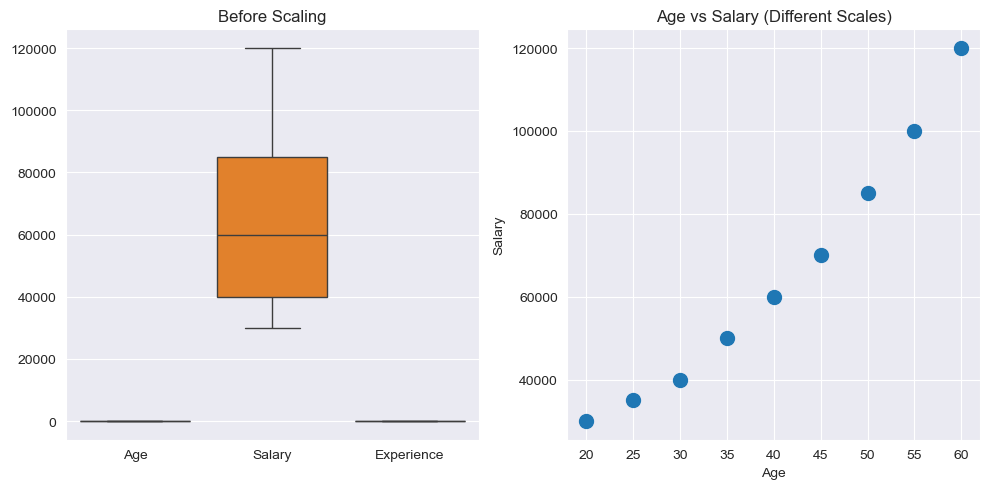

In [23]:
# Create sample data
data = {
    "Age": [20, 25, 30, 35, 40, 45, 50, 55, 60],
    "Salary": [30000, 35000, 40000, 50000, 60000, 70000, 85000, 100000, 120000],
    "Experience": [1, 2, 3, 5, 7, 9, 12, 15, 20]
}
df = pd.DataFrame(data)
print("Original Data:\n", df)
#visualize scales
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
sns.boxplot(data=df)
plt.title("Before Scaling")
plt.subplot(1, 2, 2)
plt.grid()
plt.scatter(df["Age"], df["Salary"], s=100)
plt.xlabel("Age")
plt.ylabel("Salary")
plt.title("Age vs Salary (Different Scales)")
plt.grid()
plt.tight_layout()
plt.show()

## 2. StandardScaler (Z-Score Normalization)

Transforms to mean=0, standard deviation=1

Formula: **(x - mean) / std**

Mean of each column-.fit(),   
Standard deviation of each column-.fit()

After StandardScaler:
         Age    Salary  Experience
0 -1.549193 -1.217778   -1.193515
1 -1.161895 -1.046528   -1.028259
2 -0.774597 -0.875278   -0.863003
3 -0.387298 -0.532778   -0.532491
4  0.000000 -0.190278   -0.201979
5  0.387298  0.152222    0.128532
6  0.774597  0.665972    0.624300
7  1.161895  1.179722    1.120068
8  1.549193  1.864723    1.946347

Mean:
 Age           0.000000e+00
Salary       -1.973730e-16
Experience    1.233581e-16
dtype: float64

Std:
 Age           1.06066
Salary        1.06066
Experience    1.06066
dtype: float64


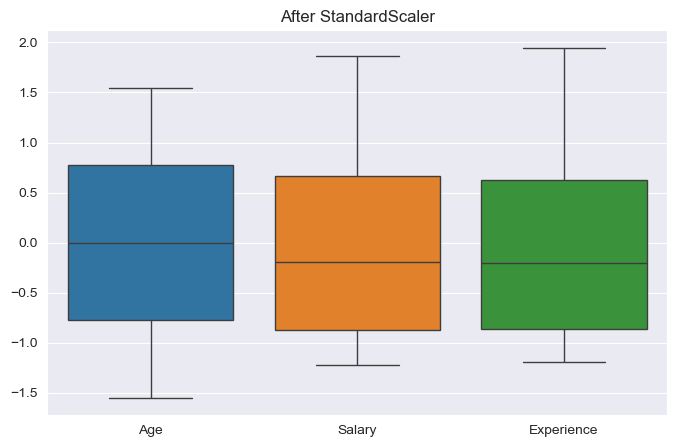

In [27]:
scaler_standard=StandardScaler()
df_standard=pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)
print("After StandardScaler:\n", df_standard)
print("\nMean:\n", df_standard.mean())
print("\nStd:\n", df_standard.std())
# OR
#scaler_standard.fit(df)
#scaled = scaler_standard.transform(df)
# Visualize
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_standard)
plt.title("After StandardScaler")
plt.show()

 3. MinMaxScaler (Normalization)

Transforms to range [0, 1]

Formula: **(x - min) / (max - min)**

After MinMaxScaler:
      Age    Salary  Experience
0  0.000  0.000000    0.000000
1  0.125  0.055556    0.052632
2  0.250  0.111111    0.105263
3  0.375  0.222222    0.210526
4  0.500  0.333333    0.315789
5  0.625  0.444444    0.421053
6  0.750  0.611111    0.578947
7  0.875  0.777778    0.736842
8  1.000  1.000000    1.000000

Min:
 Age           0.0
Salary        0.0
Experience    0.0
dtype: float64

Max:
 Age           1.0
Salary        1.0
Experience    1.0
dtype: float64


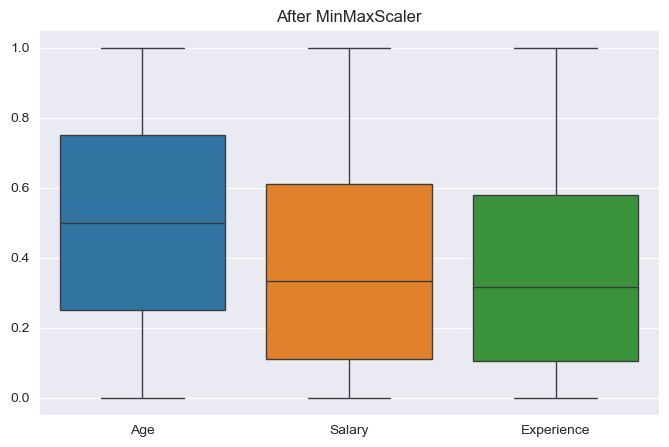

In [32]:
#min max scaler
scaler_minmax=MinMaxScaler()
df_minmax=pd.DataFrame(
    scaler_minmax.fit_transform(df),columns=df.columns)
print("After MinMaxScaler:\n", df_minmax)
print("\nMin:\n", df_minmax.min())
print("\nMax:\n", df_minmax.max())
# Visualize
plt.figure(figsize=(8, 5))
sns.boxplot(data=df_minmax)
plt.title("After MinMaxScaler")
plt.show()

. Train-Test Split

Split data into training and testing sets.
- Train: 80% → Model learns from this
- Test: 20% → Evaluate model performance

In [35]:
#create features (x) and target(y)
#Let's predict salary based on Age and Experience
X = df[["Age", "Experience"]]  # Features
y = df["Salary"]                # Target
print("Features (X):\n", X.head())
print("\nTarget (y):\n", y.head())
# Split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nX_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("\nX_train:\n", X_train)
print("\nX_test:\n", X_test)

Features (X):
    Age  Experience
0   20           1
1   25           2
2   30           3
3   35           5
4   40           7

Target (y):
 0    30000
1    35000
2    40000
3    50000
4    60000
Name: Salary, dtype: int64

X_train shape: (7, 2)
X_test shape: (2, 2)
y_train shape: (7,)
y_test shape: (2,)

X_train:
    Age  Experience
5   45           9
0   20           1
8   60          20
2   30           3
4   40           7
3   35           5
6   50          12

X_test:
    Age  Experience
7   55          15
1   25           2


5. Combine: Scale AFTER Splitting

Important rule: **Fit scaler on training data only, then transform both train and test**

In [37]:
# Step 1: Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# Step 2: Fit scaler on TRAIN only
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
# Step 3: Transform TEST with same scaler
X_test_scaled = scaler.transform(X_test)
print("X_train_scaled (first 3):\n", X_train_scaled[:3])
print("\nX_test_scaled:\n", X_test_scaled)
# Why this order matters:
# - Prevents data leakage from test to train
# - Real-world scenario: you only have training data when building model

X_train_scaled (first 3):
 [[ 0.40824829  0.14492585]
 [-1.63299316 -1.20771538]
 [ 1.63299316  2.00480752]]

X_test_scaled:
 [[ 1.22474487  1.15940676]
 [-1.22474487 -1.03863522]]


6. Challenge: Complete ML Preparation Pipeline

In [38]:
# Use your cleaned Titanic dataset from Day 9
titanic = pd.read_csv("titanic_clean.csv")
# Select numeric features for simplicity
features = ["pclass", "age", "sibsp", "parch", "fare"]
target = "survived"
X = titanic[features]
y = titanic[target]
print("Features:\n", X.head())
print("\nTarget:\n", y.head())
# Check for any remaining missing values
print("\nMissing in X:\n", X.isnull().sum())
# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
# stratify=y ensures same proportion of survived/not-survived in both sets
print(f"\nTrain size: {len(X_train)}, Test size: {len(X_test)}")
# 2. Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
# 3. Check results
print("\nX_train original (first 3):\n", X_train.head(3))
print("\nX_train scaled (first 3):\n", X_train_scaled[:3])
print("\nData ready for Machine Learning!")

Features:
    pclass   age  sibsp  parch     fare
0       3  22.0      1      0   7.2500
1       1  38.0      1      0  71.2833
2       3  26.0      0      0   7.9250
3       1  35.0      1      0  53.1000
4       3  35.0      0      0   8.0500

Target:
 0    0
1    1
2    1
3    1
4    0
Name: survived, dtype: int64

Missing in X:
 pclass    0
age       0
sibsp     0
parch     0
fare      0
dtype: int64

Train size: 711, Test size: 178

X_train original (first 3):
      pclass   age  sibsp  parch      fare
620       1  42.0      1      0   52.5542
480       2  28.0      0      0    0.0000
526       1  28.0      0      0  221.7792

X_train scaled (first 3):
 [[-1.60146146  0.96794127  0.46976084 -0.4614951   0.41975379]
 [-0.39143054 -0.10787086 -0.46844129 -0.4614951  -0.6460831 ]
 [-1.60146146 -0.10787086 -0.46844129 -0.4614951   3.85175823]]

Data ready for Machine Learning!
